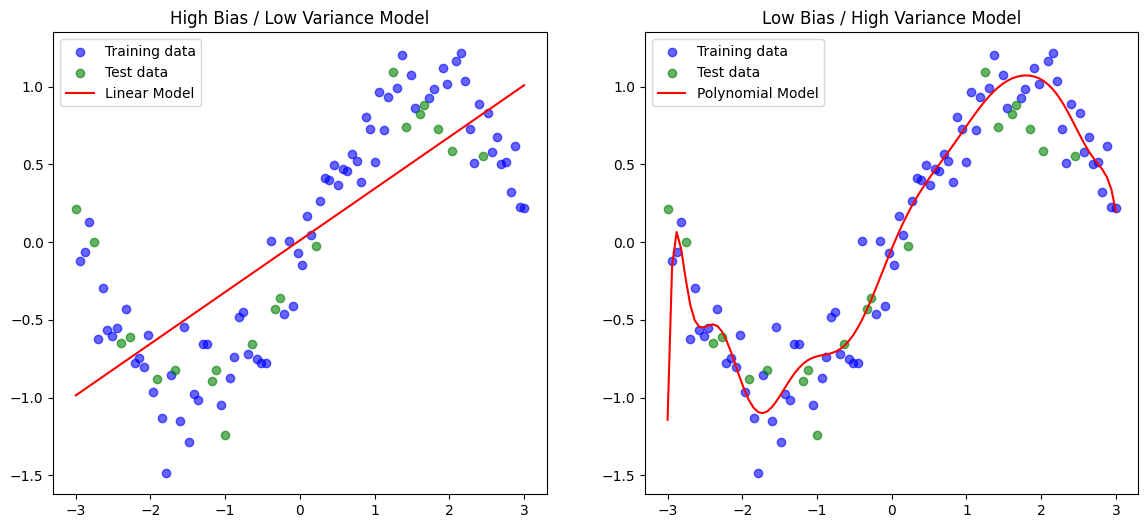

Linear Model Training MSE: 0.19743335485331392
Linear Model Testing MSE: 0.24695224333039673


Polynomial Model Training MSE: 0.029514806989774718
Polynomial Model Testing MSE: 0.1425297085836628


Linear Regression Model (High Bias/Low Variance)
Training MSE: 0.19743335485331392
Testing MSE: 0.24695224333039673



Polynomial Regression Model (Low Bias/High Variance)
Training MSE: 0.029514806989774718
Testing MSE: 0.1425297085836628





Bias - Variance of Linear Model
MSE: 0.253
Bias: 0.247
Variance: 0.006



Bias - Variance of Polynomial Model
MSE: 2.609
Bias: 0.140
Variance: 2.468


In [ ]:
# estimate the bias and variance for a regression model
# Exhibiting low bias, high variance model and high bias, low variance model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
# Generate a synthetic dataset
np.random.seed(0)
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100) # Adding noise
X = X[:, np.newaxis] # Reshape for sklearn
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# High Bias / Low Variance Model (Linear Regression)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_train_linear = linear_model.predict(X_train)
y_pred_test_linear = linear_model.predict(X_test)
# Low Bias / High Variance Model (Polynomial Regression with high degree)
poly_model = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly = poly_model.predict(X_test)
# Plotting
plt.figure(figsize=(14, 6))
# Linear Model Plot
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, label='Training data', color='blue', alpha=0.6)
plt.scatter(X_test, y_test, label='Test data', color='green', alpha=0.6)
plt.plot(X, linear_model.predict(X), color='red', label='Linear Model')
plt.title('High Bias / Low Variance Model')
plt.legend()
# Polynomial Model Plot
plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, label='Training data', color='blue', alpha=0.6)
plt.scatter(X_test, y_test, label='Test data', color='green', alpha=0.6)
plt.plot(np.linspace(-3, 3, 100), poly_model.predict(np.linspace(-3, 3,100)[:, np.newaxis]), color='red', label='Polynomial Model')
plt.title('Low Bias / High Variance Model')
plt.legend()
plt.show()
# Print Mean Squared Error for both models
print(f"Linear Model Training MSE: {mean_squared_error(y_train, y_pred_train_linear)}")
print(f"Linear Model Testing MSE: {mean_squared_error(y_test, y_pred_test_linear)}")
print("\n")
print(f"Polynomial Model Training MSE: {mean_squared_error(y_train, y_pred_train_poly)}")
print(f"Polynomial Model Testing MSE: {mean_squared_error(y_test, y_pred_test_poly)}")
print("\n")
# Calculate Mean Squared Error (MSE) for training and testing sets
mse_train_linear = mean_squared_error(y_train, y_pred_train_linear)
mse_test_linear = mean_squared_error(y_test, y_pred_test_linear)
mse_train_poly = mean_squared_error(y_train, y_pred_train_poly)
mse_test_poly = mean_squared_error(y_test, y_pred_test_poly)
# Display MSE for both models
print("Linear Regression Model (High Bias/Low Variance)")
print(f"Training MSE: {mse_train_linear}")
print(f"Testing MSE: {mse_test_linear}\n")
print("\n")
print("Polynomial Regression Model (Low Bias/High Variance)")
print(f"Training MSE: {mse_train_poly}")
print(f"Testing MSE: {mse_test_poly}")
print("\n")

from mlxtend.evaluate import bias_variance_decomp
mse, bias, var = bias_variance_decomp(linear_model, X_train, y_train, X_test, y_test, loss='mse', num_rounds=200, random_seed=1)
# summarize results
print('\n\n')
print('Bias - Variance of Linear Model')
print('MSE: %.3f' % mse)
print('Bias: %.3f' % bias)
print('Variance: %.3f' % var)
mse, bias, var = bias_variance_decomp(poly_model, X_train, y_train, X_test, y_test, loss='mse', num_rounds=200, random_seed=1)
# summarize results
print('\n\n')
print('Bias - Variance of Polynomial Model')
print('MSE: %.3f' % mse)
print('Bias: %.3f' % bias)
print('Variance: %.3f' % var)

Assignment Low Bias/Low variance

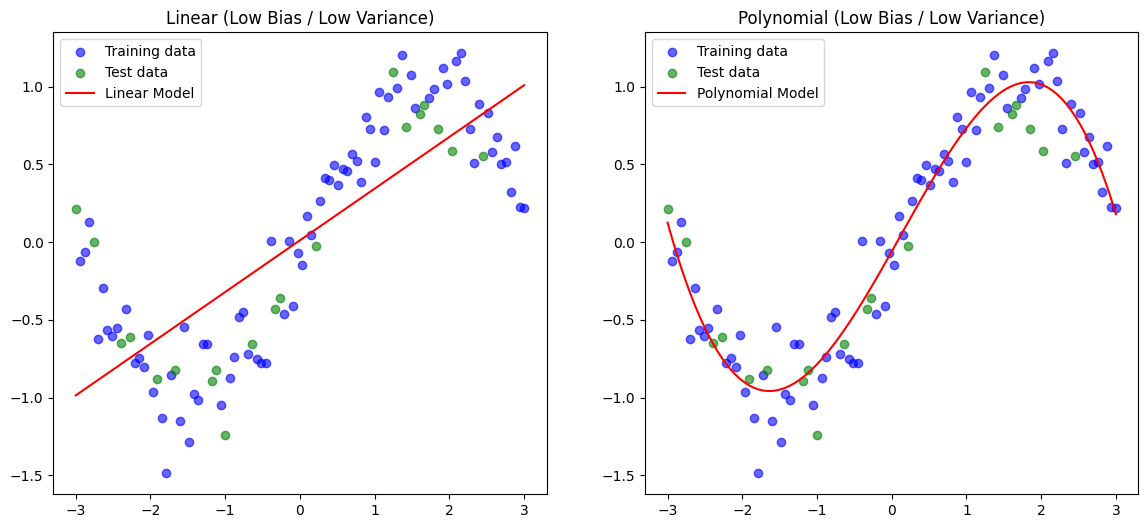

Linear Model Training MSE: 0.19743335485331392
Linear Model Testing MSE: 0.24695224333039673

Bias - Variance of Linear Model
MSE: 0.253
Bias: 0.247
Variance: 0.006


Polynomial Model Training MSE: 0.034392277465462945
Polynomial Model Testing MSE: 0.041525680224991667

Bias - Variance of Polynomial Model
MSE: 0.045
Bias: 0.042
Variance: 0.003


In [ ]:
# LOW BIAS / LOW VARIANCE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from mlxtend.evaluate import bias_variance_decomp

# Generate dataset
np.random.seed(0)
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100)
X = X[:, np.newaxis]

# Normal split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- Linear ----------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_train_linear = linear_model.predict(X_train)
y_pred_test_linear = linear_model.predict(X_test)

# ---------------- Polynomial (balanced) ----------------
poly_model = make_pipeline(
    PolynomialFeatures(degree=5),
    Ridge(alpha=1.0)
)
poly_model.fit(X_train, y_train)

y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly = poly_model.predict(X_test)

# ---------------- Plot ----------------
plt.figure(figsize=(14,6))

# Linear
plt.subplot(1,2,1)
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Training data')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test data')
plt.plot(X, linear_model.predict(X), color='red', label='Linear Model')
plt.title("Linear (Low Bias / Low Variance)")
plt.legend()

# Polynomial
plt.subplot(1,2,2)
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Training data')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test data')
plt.plot(X, poly_model.predict(X), color='red', label='Polynomial Model')
plt.title("Polynomial (Low Bias / Low Variance)")
plt.legend()

plt.show()

# ---------------- Results ----------------
print("Linear Model Training MSE:", mean_squared_error(y_train, y_pred_train_linear))
print("Linear Model Testing MSE:", mean_squared_error(y_test, y_pred_test_linear))

mse, bias, var = bias_variance_decomp(
    linear_model, X_train, y_train,
    X_test, y_test,
    loss='mse', num_rounds=200, random_seed=1
)

print("\nBias - Variance of Linear Model")
print("MSE: %.3f" % mse)
print("Bias: %.3f" % bias)
print("Variance: %.3f" % var)

print("\n")

print("Polynomial Model Training MSE:", mean_squared_error(y_train, y_pred_train_poly))
print("Polynomial Model Testing MSE:", mean_squared_error(y_test, y_pred_test_poly))

mse, bias, var = bias_variance_decomp(
    poly_model, X_train, y_train,
    X_test, y_test,
    loss='mse', num_rounds=200, random_seed=1
)

print("\nBias - Variance of Polynomial Model")
print("MSE: %.3f" % mse)
print("Bias: %.3f" % bias)
print("Variance: %.3f" % var)


High Bias/ High Variance

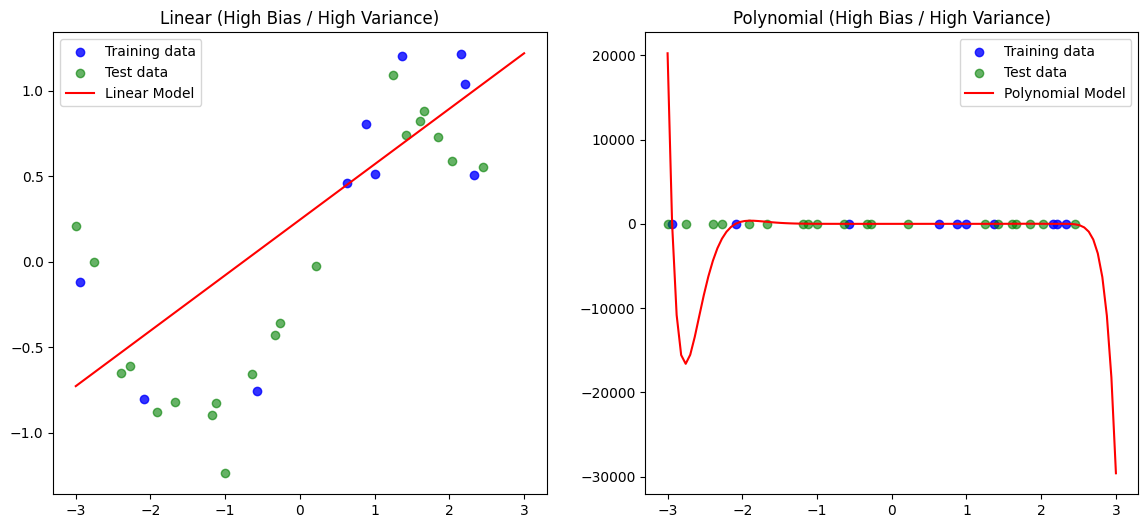

Linear Model Training MSE: 0.1811716081117703
Linear Model Testing MSE: 0.30139765378090844

Bias - Variance of Linear Model
MSE: 0.384
Bias: 0.292
Variance: 0.091


Polynomial Model Training MSE: 1.2074847170706594e-21
Polynomial Model Testing MSE: 35368838.221896544

Bias - Variance of Polynomial Model
MSE: 41793822606.081
Bias: 110291417.885
Variance: 41683531188.196


In [ ]:
# HIGH BIAS / HIGH VARIANCE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from mlxtend.evaluate import bias_variance_decomp

# Generate dataset
np.random.seed(0)
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100)
X = X[:, np.newaxis]

# Small training set (causes high variance)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, _, y_train, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=10,
    random_state=1
)

# ---------------- Linear ----------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_train_linear = linear_model.predict(X_train)
y_pred_test_linear = linear_model.predict(X_test)

# ---------------- Polynomial ----------------
poly_model = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)
poly_model.fit(X_train, y_train)

y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly = poly_model.predict(X_test)

# ---------------- Plot ----------------
plt.figure(figsize=(14,6))

# Linear
plt.subplot(1,2,1)
plt.scatter(X_train, y_train, color='blue', alpha=0.8, label='Training data')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test data')
plt.plot(X, linear_model.predict(X), color='red', label='Linear Model')
plt.title("Linear (High Bias / High Variance)")
plt.legend()

# Polynomial
plt.subplot(1,2,2)
plt.scatter(X_train, y_train, color='blue', alpha=0.8, label='Training data')
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Test data')
plt.plot(X, poly_model.predict(X), color='red', label='Polynomial Model')
plt.title("Polynomial (High Bias / High Variance)")
plt.legend()

plt.show()

# ---------------- Results ----------------
print("Linear Model Training MSE:", mean_squared_error(y_train, y_pred_train_linear))
print("Linear Model Testing MSE:", mean_squared_error(y_test, y_pred_test_linear))

mse, bias, var = bias_variance_decomp(
    linear_model, X_train, y_train,
    X_test, y_test,
    loss='mse', num_rounds=200, random_seed=1
)

print("\nBias - Variance of Linear Model")
print("MSE: %.3f" % mse)
print("Bias: %.3f" % bias)
print("Variance: %.3f" % var)

print("\n")

print("Polynomial Model Training MSE:", mean_squared_error(y_train, y_pred_train_poly))
print("Polynomial Model Testing MSE:", mean_squared_error(y_test, y_pred_test_poly))

mse, bias, var = bias_variance_decomp(
    poly_model, X_train, y_train,
    X_test, y_test,
    loss='mse', num_rounds=200, random_seed=1
)

print("\nBias - Variance of Polynomial Model")
print("MSE: %.3f" % mse)
print("Bias: %.3f" % bias)
print("Variance: %.3f" % var)
